[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/mimic_to_json.ipynb)

## Download Physionet MIMIC IV datasets
Here we download only the demo release (no credentials and 100 patients) of the Physionet MIMIC-IV database for the purpose of showing how the workflow works. In order to get the JSON format of the MIMIC-IV asplenic cohort you need to get credentials from Physionet.

In [25]:
try:
    import google.colab
    print("Running in Colab! ... downloading everything...")
    %mkdir data
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/patients.csv.gz -O data/patients.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/admissions.csv.gz -O data/admissions.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/diagnoses_icd.csv.gz -O data/diagnoses_icd.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/d_icd_diagnoses.csv.gz -O data/d_icd_diagnoses.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/procedures_icd.csv.gz -O data/procedures_icd.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/d_icd_procedures.csv.gz -O data/d_icd_procedures.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/prescriptions.csv.gz -O data/prescriptions.csv.gz
    !wget -np https://physionet.org/files/mimic-iv-demo/2.2/hosp/emar.csv.gz -O data/emar.csv.gz
    !gunzip -f data/*.gz
except:
  print("Not running in Colab ... or enable to get Physionet database!")


Not running in Colab ... or enable to get Physionet database!


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os

def read_csv(filename):
    total_lines = sum(1 for _ in open(filename))
    with tqdm(total=int(total_lines), desc=f'Loading {os.path.basename(filename)}:') as bar:
        # do not skip any of the rows, but update the progress bar instead
        filecontent = pd.read_csv(filename, skiprows=lambda x: bar.update(1) and False)
    return filecontent

DATA_PATH = "data" #"<your-path-to-mimic-iv-datafiles>"

patients = read_csv(os.path.join(DATA_PATH, "patients.csv"))
admissions = read_csv(os.path.join(DATA_PATH, "admissions.csv"))
diagnoses = read_csv(os.path.join(DATA_PATH, "diagnoses_icd.csv"))
d_icd_diag = read_csv(os.path.join(DATA_PATH, "d_icd_diagnoses.csv"))
procedures = read_csv(os.path.join(DATA_PATH, "procedures_icd.csv"))
d_icd_proc = read_csv(os.path.join(DATA_PATH, "d_icd_procedures.csv"))
emar = read_csv(os.path.join(DATA_PATH, "emar.csv"))

Loading patients.csv::   0%|          | 0/364628 [00:00<?, ?it/s]

Loading admissions.csv::   0%|          | 0/546029 [00:00<?, ?it/s]

Loading diagnoses_icd.csv::   0%|          | 0/6364489 [00:00<?, ?it/s]

Loading d_icd_diagnoses.csv::   0%|          | 0/112108 [00:00<?, ?it/s]

Loading procedures_icd.csv::   0%|          | 0/859656 [00:00<?, ?it/s]

Loading d_icd_procedures.csv::   0%|          | 0/86424 [00:00<?, ?it/s]

Loading emar.csv::   0%|          | 0/42808594 [00:00<?, ?it/s]

## Download Github files

In [27]:
try:
    import google.colab
    %mkidr files
    !wget -np https://github.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/files/CHA.csv -O files/CHA.csv
    !wget -np https://github.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/files/Immunodef.csv -O files/Immunodef.csv
    !wget -np https://github.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/files/Onco.csv -O files/Onco.csv
    !wget -np https://github.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/files/SCD.csv -O files/SCD.csv
    !wget -np https://github.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/files/Thalassemia.csv -O files/Thalassemia.csv
    print("Working on Colab!")
except:
    print("Not Working on Colab ... or cannot dwnload Github files!")
    pass

Not Working on Colab ... or cannot dwnload Github files!


## Select patients with primary disease == asplenia

In [28]:
import pandas as pd
import os
FILES_PATH = "files" # "your-path-to-ICD-files"
onco_codes = pd.read_csv(os.path.join(FILES_PATH, "Onco.csv"), names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
cha_codes = pd.read_csv(os.path.join(FILES_PATH, "CHA.csv"), names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
thala_codes = pd.read_csv(os.path.join(FILES_PATH, "Thalassemia.csv"), names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
scd_codes = pd.read_csv(os.path.join(FILES_PATH, "SCD.csv"), names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
imm_codes = pd.read_csv(os.path.join(FILES_PATH, "Immunodef.csv"), names=['icd_code', 'icd_version', 'long_title'], sep=';', comment='#')
spleen_codes = pd.concat([onco_codes,cha_codes,thala_codes,scd_codes,imm_codes])
spleen_codes

,icd_code,icd_version,long_title
0,1537,9,Malignant neoplasm of splenic flexure
1,2894,9,Hypersplenism
2,28951,9,Chronic congestive splenomegaly
3,28953,9,Neutropenic splenomegaly
4,44283,9,Aneurysm of splenic artery
...,...,...,...
16,D838,10,Other common variable immunodeficiencies
17,D839,10,"Common variable immunodeficiency, unspecified"
18,D84,10,Other immunodeficiencies
19,D848,10,Other specified immunodeficiencies


Pre-admission absence of spleen found: 450
Asplenic disease found: 3877
Splenectomized patients found: 544
Total patients patients: 4133


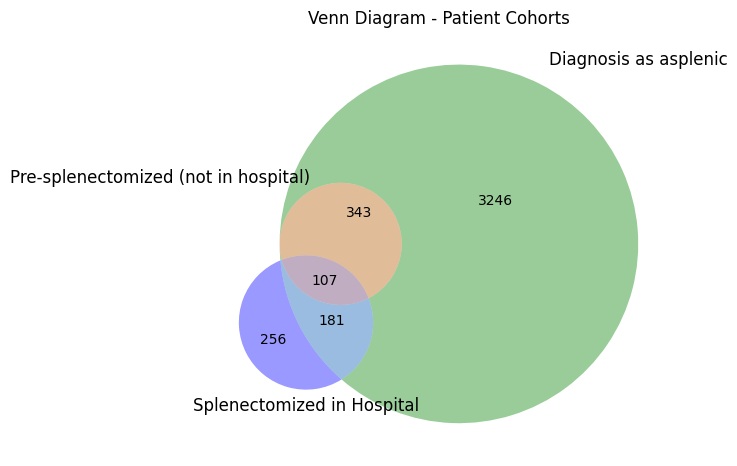

In [ ]:
diagnoses_full = diagnoses.merge(
    d_icd_diag,
    on=["icd_code", "icd_version"],
    how="left"
)

# Identify all patients who have a history of splenectomy (during any hospitalization) 
no_spleen_diag = diagnoses_full[
    diagnoses_full["long_title"].str.contains(
        "asplenia|absence of spleen|absence and malformations of spleen|postsplenectomy",
        case=False,
        na=False
    )
]
no_spleen_patients = list(set(no_spleen_diag["subject_id"]))
print(f"Pre-admission absence of spleen found: {len(no_spleen_patients)}")

# Identify patients whose recorded diagnosis for a hospital admission is one of the categories identified as asplenic
asplenia_diag = diagnoses_full[(diagnoses_full["icd_code"].isin(spleen_codes['icd_code'].values))]
asplenic_patients = list(set(asplenia_diag["subject_id"]))
print(f"Asplenic disease found: {len(asplenic_patients)}")

# Identify patients who underwent one (or more) splenectomies during any hospital stay 
# and determines their "age_at_splenectomy"
procedures["icd_code_clean"] = procedures["icd_code"].str.replace(".", "", regex=False)

splenectomy = procedures[
    (procedures["icd_code_clean"].str.startswith("415")) |
    (procedures["icd_code_clean"].str.startswith("414")) |
    (procedures["icd_code_clean"].str.startswith("07TP"))
]
splenectomy_full = splenectomy.merge(
    d_icd_proc,
    on=["icd_code", "icd_version"],
    how="left"
)
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
splenectomy_full = splenectomy_full.merge(
    admissions[["subject_id", "hadm_id", "admittime"]],
    on=["subject_id", "hadm_id"],
    how="left"
)
splenectomy_full = splenectomy_full.merge(
    patients[["subject_id", "anchor_age", "anchor_year"]],
    on="subject_id",
    how="left"
)
splenectomy_full["event_year"] = splenectomy_full["admittime"].dt.year

splenectomy_full["age_at_splenectomy"] = (
    splenectomy_full["anchor_age"] +
    (splenectomy_full["event_year"] - splenectomy_full["anchor_year"])
)
splenectomized_patients = list(set(splenectomy_full["subject_id"]))
print(f"Splenectomized patients found: {len(splenectomized_patients)}")

all_asplenic_patients = list(set(no_spleen_patients) | set(splenectomized_patients) | set(asplenic_patients))
print(f"Total patients patients: {len(all_asplenic_patients)}")

## Compare Venn diagrams of sets
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

A = set(no_spleen_patients)
B = set(asplenic_patients)
C = set(splenectomized_patients)

plt.figure(figsize=(6,6))

venn3([A, B, C],
      set_labels=('Pre-splenectomized (not in hospital)' if len(A) > 0 else '', 
                  'Diagnosis as asplenic' if len(B) > 0 else '', 
                  'Splenectomized in Hospital' if len(C) > 0 else ''))

plt.title("Venn Diagram - Patient Cohorts")
plt.show()

## Filter patients by disease

In [30]:
selected_idxs = all_asplenic_patients
diagnoses = diagnoses[diagnoses["subject_id"].isin(selected_idxs)]
procedures = procedures[procedures["subject_id"].isin(selected_idxs)]
admissions = admissions[admissions["subject_id"].isin(selected_idxs)]
emar = emar[emar["subject_id"].isin(selected_idxs)]
patients = patients[patients["subject_id"].isin(selected_idxs)]

## Gender and age distribution of patients

In [31]:
patients['primary_disease'] = patients['subject_id'].apply(lambda x:
    "OD - Oncological Diseases" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(onco_codes['icd_code'].values).any()
    else "CHA - Congenital Hemolytic Anemias" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(cha_codes['icd_code'].values).any()
    else "THA - Thalassemia" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(thala_codes['icd_code'].values).any()
    else "AIHD - Autoimmune Hematological Diseases" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(imm_codes['icd_code'].values).any()
    else "SCD - Sicke Cell Disease" if asplenia_diag[asplenia_diag['subject_id'] == x]['icd_code'].isin(scd_codes['icd_code'].values).any()
    else "SP - Splenectomized"
)


In [32]:
patients['primary_disease'].value_counts()

primary_disease
OD - Oncological Diseases                   2686
CHA - Congenital Hemolytic Anemias           770
SP - Splenectomized                          256
AIHD - Autoimmune Hematological Diseases     218
THA - Thalassemia                            186
SCD - Sicke Cell Disease                      17
Name: count, dtype: int64

In [33]:
patients['age_group'] = patients['anchor_age'].apply(lambda x: "young" if x < 35 else "mature" if x < 55 else "elder" if x < 75 else "geriatric")
counts = patients.groupby(['age_group', 'gender']).size().unstack(fill_value=0)
print(counts.to_latex())

\begin{tabular}{lrr}
\toprule
gender & F & M \\
age_group &  &  \\
\midrule
elder & 831 & 959 \\
geriatric & 332 & 341 \\
mature & 536 & 578 \\
young & 286 & 270 \\
\bottomrule
\end{tabular}



In [34]:
admissions['admission_location'].value_counts()

admission_location
EMERGENCY ROOM                            9276
PHYSICIAN REFERRAL                        6271
TRANSFER FROM HOSPITAL                    2287
WALK-IN/SELF REFERRAL                     2202
CLINIC REFERRAL                            983
PROCEDURE SITE                             423
TRANSFER FROM SKILLED NURSING FACILITY     285
PACU                                       164
INTERNAL TRANSFER TO OR FROM PSYCH          55
INFORMATION NOT AVAILABLE                   18
AMBULATORY SURGERY TRANSFER                 14
Name: count, dtype: int64

## Compute events

### calcola i farmaci dalla tabell `emar.csv`

In [35]:
import re
VACCINATION_KEYWORDS = r"(influenza|flu)|(pneumo\w*)|(mening\w*)|(hepatitis\s*b?)|(tdap|tetanus|diphtheria|pertussis)|(hib)|(covid)"
EXCLUDE_PATTERN = r"(flut|fluc|fluor|flush|fluid|test|panel)"

def is_vaccine(text):
    if pd.isna(text):
        return False
    text = str(text)
    if re.search(EXCLUDE_PATTERN, text, re.IGNORECASE):
        return False
    return bool(re.search(VACCINATION_KEYWORDS, text, re.IGNORECASE))

emar_events = emar[[
    "subject_id",
    "medication",
    "charttime"
]].copy()

emar_events = emar_events.rename(columns={
    "medication": "event",
    "charttime": "event_date"
})
emar_events["event_date"] = pd.to_datetime(emar_events["event_date"]).dt.date

emar_events["type"] = emar_events["event"].apply(
    lambda x: "vaccination" if is_vaccine(x) else "drug"
)
emar_events["code"] = emar_events["event"]
emar_events["code_type"] = "EMAR-MED"
emar_events.head()

,subject_id,event,event_date,type,code,code_type
14965,10004235,Sodium Chloride 0.9% Flush,2196-06-20,drug,Sodium Chloride 0.9% Flush,EMAR-MED
14966,10004235,NaN,2196-06-20,drug,NaN,EMAR-MED
14967,10004235,Pantoprazole,2196-06-20,drug,Pantoprazole,EMAR-MED
14968,10004235,Metoprolol Tartrate,2196-06-20,drug,Metoprolol Tartrate,EMAR-MED
14969,10004235,Piperacillin-Tazobactam,2196-06-20,drug,Piperacillin-Tazobactam,EMAR-MED


In [36]:
emar_events['type'].value_counts()

type
drug           2910172
vaccination       8916
Name: count, dtype: int64

### calcola le terapie, interventi

In [37]:
import re

SURGERY_KEYWORDS = r"(surgery|excision|resection|repair|removal|laparotomy|amputation|splenectomy)"
SPLENECTOMY_KEYWORDS = r"(splenectomy|removal of spleen|spleen excision)"
NON_SURGICAL_KEYWORDS = r"(insertion|catheter|infusion|dialysis|ventilation|biopsy)"

def classify_procedure(text):
    if pd.isna(text):
        return "unknown"
    
    t = str(text).lower()

    if re.search(SPLENECTOMY_KEYWORDS, t):
        return "surgery" # "splenetomy"

    if re.search(SURGERY_KEYWORDS, t):
        return "surgery"

    if re.search(NON_SURGICAL_KEYWORDS, t):
        return "therapy"

    return "therapy" # "other_procedure"

procedures_m = procedures.merge(
    d_icd_proc[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)
proc_join = procedures_m.merge(
    admissions[["hadm_id", "admittime", "subject_id"]],
    on="hadm_id",
    how="left",
    suffixes=('', '_remove')
)
proc_join["event_date"] = pd.to_datetime(proc_join["admittime"]).dt.date
proc_join["type"] = proc_join["long_title"].apply(classify_procedure)

proc_join["event"] = proc_join["long_title"]

proc_events = proc_join[[
    "subject_id",
    "event",
    "event_date",
    "icd_code",
    "icd_version",
    "type"
]].copy()
proc_events.rename(columns={'icd_code':'code'}, inplace=True)
def map_code_type(v):
    if pd.isna(v):
        return None
    if str(v) in ["9", 9]:
        return "ICD-9-PCS"
    if str(v) in ["10", 10]:
        return "ICD-10-PCS"
    return "UNKNOWN"

proc_events["code_type"] = proc_events["icd_version"].apply(map_code_type)
proc_events.head()

,subject_id,event,event_date,code,icd_version,type,code_type
0,10004235,Continuous invasive mechanical ventilation for...,2196-02-24,9671,9,therapy,ICD-9-PCS
1,10004235,Hemodialysis,2196-02-24,3995,9,therapy,ICD-9-PCS
2,10004235,Central venous catheter placement with guidance,2196-02-24,3897,9,therapy,ICD-9-PCS
3,10004235,Arterial catheterization,2196-02-24,3891,9,therapy,ICD-9-PCS
4,10004235,Endoscopic insertion of stent (tube) into bile...,2196-02-24,5187,9,therapy,ICD-9-PCS


In [38]:
import re

INFECTION_PATTERN = r"""
(sepsis|septicaemia|septic|infection|infect|pneumonia|
abscess|cellulitis|meningitis|encephalitis|endocarditis|
bacteremia|fungal|viral|tb|tuberculosis|urinary tract infection|uti)
"""
def is_infection(text):
    if pd.isna(text):
        return False
    
    return bool(
        re.search(INFECTION_PATTERN, str(text), re.IGNORECASE | re.VERBOSE)
    )

diagnoses_m = diagnoses.merge(
    d_icd_diag[["icd_code", "long_title"]],
    on="icd_code",
    how="left"
)
diag_join = diagnoses_m.merge(
    admissions[["hadm_id", "admittime", "subject_id"]],
    on="hadm_id",
    how="left",
    suffixes=('', '_remove')
)
diag_join["event_date"] = pd.to_datetime(diag_join["admittime"]).dt.date

diagnosis_events = diag_join[[
    "subject_id", "icd_code", "icd_version", "event_date", "long_title"
]].rename(columns={
    "long_title": "event", "icd_code" : "code"
})
diagnosis_events["type"] = diagnosis_events["event"].apply(
    lambda x: "infection" if is_infection(x) else "disease"
)
diagnosis_events["code_type"] = diagnosis_events['icd_version'].apply(lambda x: f"ICD-{x}-CM")
diagnosis_events.head()

,subject_id,code,icd_version,event_date,event,type,code_type
0,10004235,78062,9,2196-06-20,Postprocedural fever,disease,ICD-9-CM
1,10004235,V1253,9,2196-06-20,Personal history of sudden cardiac arrest,disease,ICD-9-CM
2,10004235,29900,9,2196-06-20,"Autistic disorder, current or active state",infection,ICD-9-CM
3,10004235,4019,9,2196-06-20,Unspecified essential hypertension,disease,ICD-9-CM
4,10004235,V5861,9,2196-06-20,Long-term (current) use of anticoagulants,disease,ICD-9-CM


In [39]:
all_events = pd.concat([
    diagnosis_events,
    proc_events,
    emar_events,
], ignore_index=True)

# Remove events with no data
all_events = all_events.dropna(subset=["event_date"])

# Convert patient id into string for JSON
all_events["subject_id"] = all_events["subject_id"].astype(str)
all_events["type"].value_counts()
all_events

,subject_id,code,icd_version,event_date,event,type,code_type
0,10004235,78062,9.0,2196-06-20,Postprocedural fever,disease,ICD-9-CM
1,10004235,V1253,9.0,2196-06-20,Personal history of sudden cardiac arrest,disease,ICD-9-CM
2,10004235,29900,9.0,2196-06-20,"Autistic disorder, current or active state",infection,ICD-9-CM
3,10004235,4019,9.0,2196-06-20,Unspecified essential hypertension,disease,ICD-9-CM
4,10004235,V5861,9.0,2196-06-20,Long-term (current) use of anticoagulants,disease,ICD-9-CM
...,...,...,...,...,...,...,...
3299664,19997367,Heparin,NaN,2128-01-21,Heparin,drug,EMAR-MED
3299665,19997367,Midodrine,NaN,2128-01-21,Midodrine,drug,EMAR-MED
3299666,19997367,Heparin Flush (100 units/ml),NaN,2128-01-21,Heparin Flush (100 units/ml),drug,EMAR-MED
3299667,19997367,Sodium Chloride 0.9% Flush,NaN,2128-01-21,Sodium Chloride 0.9% Flush,drug,EMAR-MED


## Extract info of patients with multiple admissions

In [40]:
multi_admit = admissions.groupby("subject_id").size().reset_index(name="num_admissions")
multi_admit = multi_admit[multi_admit["num_admissions"] > 1]
admissions_multi = admissions[admissions["subject_id"].isin(multi_admit["subject_id"])]
admissions_multi

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
266,10004235,22187210,2196-06-20 21:11:00,2196-06-22 13:30:00,NaN,DIRECT EMER.,P01BF7,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,BLACK/CAPE VERDEAN,NaN,NaN,0
267,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P61V4U,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,English,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
268,10004235,25970245,2196-06-14 08:30:00,2196-06-19 14:54:00,NaN,SURGICAL SAME DAY ADMISSION,P17UWG,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,BLACK/CAPE VERDEAN,NaN,NaN,0
275,10004401,21085166,2141-06-06 19:20:00,2141-06-09 12:34:00,NaN,EW EMER.,P00HGT,EMERGENCY ROOM,HOME,Medicare,English,MARRIED,WHITE,2141-06-06 16:48:00,2141-06-06 20:19:00,0
276,10004401,22869003,2144-04-05 09:31:00,2144-04-09 17:30:00,NaN,EW EMER.,P43MIV,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,MARRIED,WHITE,2144-04-05 08:17:00,2144-04-05 10:57:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545858,19997367,24169669,2128-02-19 17:40:00,2128-02-26 16:10:00,NaN,DIRECT EMER.,P34QXU,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,MARRIED,WHITE,NaN,NaN,0
545859,19997367,25038503,2126-03-13 18:14:00,2126-03-18 17:49:00,NaN,EW EMER.,P50YJZ,EMERGENCY ROOM,HOME,Medicare,English,MARRIED,WHITE,2126-03-13 14:57:00,2126-03-13 20:10:00,0
545860,19997367,27185507,2127-05-05 02:40:00,2127-05-12 16:52:00,NaN,URGENT,P03ZWF,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,English,MARRIED,WHITE,2127-05-04 22:17:00,2127-05-05 19:25:00,0
545861,19997367,27445461,2127-08-19 00:20:00,2127-08-21 17:10:00,NaN,EW EMER.,P32CSX,EMERGENCY ROOM,HOME,Medicare,English,MARRIED,WHITE,2127-08-18 20:10:00,2127-08-19 03:48:00,0


## Concat all together

In [41]:
from collections import defaultdict
import json

patient_dict = defaultdict(list)

for _, row in tqdm(all_events.iterrows(), total=len(all_events), desc='Processing Events'):
    subj_id = row["subject_id"]
    event_entry = {
        "type": row["type"],
        "event": str(row["event"]),
        "date": str(row["event_date"]),
        "code": str(row["code"]),
        "code_type": str(row["code_type"]),
        "code_descr": str(row["event"])
    }
    patient_dict[subj_id].append(event_entry)


for subj_id, events in tqdm(patient_dict.items(), total=len(patient_dict), desc='Events to Patients'):
    events_sorted = sorted(
        events,
        key=lambda e: e["date"]
    )
    patient_dict[subj_id] = events_sorted

Processing Events:   0%|          | 0/3299669 [00:00<?, ?it/s]

Events to Patients:   0%|          | 0/4133 [00:00<?, ?it/s]

## Show the outcome of last admission 
For each patient:

+ find last admission time (`admittime`)

+ take `hospital_expire_flag` of last admision (dead or alive)

In [42]:
admissions["admittime"] = pd.to_datetime(admissions["admittime"])

# Find last admission per patient
last_adm = admissions.sort_values("admittime").groupby("subject_id").tail(1)

# Keep only subject_id and expire flag
last_adm = last_adm[["subject_id", "hospital_expire_flag"]]

# Convert subject_id a string (come nel tuo patient_dict)
last_adm["subject_id"] = last_adm["subject_id"].astype(str)
last_adm

,subject_id,hospital_expire_flag
113476,12106780,0
198696,13655271,0
146808,12708660,0
366161,16713166,0
535034,19799529,0
...,...,...
162340,12984454,0
154400,12844772,1
305034,15589086,0
200443,13686614,0


## Stampa cause di morte

In [43]:

admissions["admittime"] = pd.to_datetime(admissions["admittime"])

# Last admission per patient
last_adm = admissions.sort_values("admittime").groupby("subject_id").last().reset_index()

# Patients who died at the hospital
dead = last_adm[last_adm["hospital_expire_flag"] == 1]

# Join on diagnoses
dead_diag = dead.merge(diagnoses, on=["subject_id", "hadm_id"])

# Primary diagnosis
cause_of_death = dead_diag[dead_diag["seq_num"] == 1]

# Join ICD descriptions
cause_of_death = cause_of_death.merge(
    d_icd_diag,
    on=["icd_code", "icd_version"],
    how="left"
)

# Final output
cause_of_death[[
    "subject_id",
    "hadm_id",
    "icd_code",
    "long_title",
]]

cause_of_death = cause_of_death.rename(columns={"long_title": "cause_of_death"})
cod_df = cause_of_death[["subject_id", "cause_of_death"]].drop_duplicates()

## Prendi genere e altre info da PATIENTS
+ Merge informazioni statiche

In [44]:
patients.columns

Index(['subject_id', 'gender', 'anchor_age', 'anchor_year',
       'anchor_year_group', 'dod', 'primary_disease', 'age_group'],
      dtype='object')

In [45]:
# Select useful columns
patients_info = patients[["subject_id", "gender", "age_group", "primary_disease"]]
patient_static = patients_info.merge(
    last_adm,
    on="subject_id",
    how="left"
)
patient_static

patient_static = patient_static.merge(
    cod_df,
    on="subject_id",
    how="left"
)
patient_static['cause_of_death'].value_counts()

cause_of_death
Sepsis, unspecified organism                                             48
Unspecified septicemia                                                   33
Encounter for palliative care                                            28
Other specified sepsis                                                   13
Alcoholic cirrhosis of liver with ascites                                 9
                                                                         ..
Acute (reversible) ischemia of intestine, part and extent unspecified     1
Malignant neoplasm of corpus uteri, except isthmus                        1
Alcoholic hepatic failure without coma                                    1
Acute lymphoblastic leukemia not having achieved remission                1
Dissection of thoracoabdominal aorta                                      1
Name: count, Length: 307, dtype: int64

In [46]:
patient_static['hospital_expire_flag'].value_counts(dropna=False)

hospital_expire_flag
0    3538
1     595
Name: count, dtype: int64

In [47]:

counts = patient_static.groupby(['age_group', 'gender']).agg(
    total=('hospital_expire_flag', 'size'),          # totale pazienti
    dead=('hospital_expire_flag', 'sum')             # numero deceduti (assumendo 1=dead, 0=alive)
).unstack(fill_value=0)

print(counts.to_latex())

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{2}{r}{total} & \multicolumn{2}{r}{dead} \\
gender & F & M & F & M \\
age_group &  &  &  &  \\
\midrule
elder & 831 & 959 & 131 & 160 \\
geriatric & 332 & 341 & 59 & 72 \\
mature & 536 & 578 & 73 & 71 \\
young & 286 & 270 & 9 & 20 \\
\bottomrule
\end{tabular}



## Salva JSON file

In [ ]:
final_data = []

for subj_id, events in tqdm(patient_dict.items(), total=len(patient_dict), desc='Patients'):
    
    # Static features
    info = patient_static[patient_static["subject_id"] == int(subj_id)]
    
    if not info.empty:
        gender = info.iloc[0]["gender"]
        age_group = info.iloc[0]["age_group"]
        alive_flag = "NO" if info.iloc[0]["hospital_expire_flag"]==1 else "YES"
        primary_disease = info.iloc[0]["primary_disease"]
        cause_of_death = info.iloc[0]["cause_of_death"]
        is_splenectomized = "NO"
        age_at_splenectomy = None
        if int(subj_id) in splenectomized_patients:
            is_splenectomized = "YES"
            x = splenectomy_full[splenectomy_full['subject_id'] == int(subj_id)]['age_at_splenectomy'].values[0]
            age_at_splenectomy = 'pediatric' if x <= 12 else 'adolescent' if x < 18 else "young" if x < 35 else "mature" if x < 55 else "elder" if x < 75 else "geriatric"
        elif int(subj_id) in no_spleen_patients:
            is_splenectomized = "YES"
        else:
            is_splenectomized = "NO"
                   
    else:
        gender = None
        age_group = None
        expire_flag = None
        primary_disease = None
        cause_of_death = None
        is_splenectomized = None
    
    patient_entry = {
        "id": subj_id,
        "gender": gender,
        "age_group": age_group,
        "is_splenectomized?": is_splenectomized,
        "age_at_splenectomy": age_at_splenectomy,
        "primary_disease": primary_disease,
        "is_alive?": alive_flag if pd.notnull(alive_flag) else None,
        "cause_of_death": cause_of_death,
        "events": events
    }
    
    final_data.append(patient_entry)
import json

with open(os.path.join(DATA_PATH, f"MIMIC_dataset.json"), "w") as f:
    json.dump(final_data, f, indent=2)


Patients:   0%|          | 0/4133 [00:00<?, ?it/s]